# 💰 Project 4: Bank Customer Segmentation Using Clustering  

**Author:** Riya Vadadoria  

This notebook demonstrates how **unsupervised machine learning** can be used to segment bank customers based on their demographic and financial characteristics.  
The dataset used is the **UCI Bank Marketing Dataset** (sourced from Kaggle), which contains information from marketing campaigns of a Portuguese bank. Each record includes features such as **age, job type, account balance, housing and loan status, and campaign response**.  

---

### 📋 Workflow Overview  

1. **Data Exploration and Visualization**  
   - Examine the dataset structure, identify missing or “unknown” values, and visualize customer distributions and relationships.  

2. **Data Preprocessing**  
   - Handle missing values, encode categorical variables, and scale numerical features to prepare data for clustering.  

3. **Modeling (Clustering)**  
   - Apply **K-Means** and **Agglomerative Clustering** to identify natural customer segments.  
   - Use the **Elbow Method** and **Silhouette Score** to determine the optimal number of clusters.  

4. **Visualization and Insights**  
   - Visualize results using scatter plots and dendrograms.  
   - Interpret the customer groups and connect findings to marketing applications.  

---

### 🎯 Project Goal  
The goal of this project is to use clustering techniques to **discover distinct customer segments** that share similar financial behaviors and demographic profiles.  
These insights can help banks **personalize marketing strategies**, **design better financial products**, and **improve customer engagement**.  

---


In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [2]:
# Read the dataset
df = pd.read_csv("bank.csv")

In [3]:
# Basic Data Overview

print("Shape of dataset:", df.shape)
print("\nColumn Info:\n")
print(df.info())
print("\nMissing Values:\n")
print(df.isnull().sum())
print("\nSummary Statistics:\n")
print(df.describe())

Shape of dataset: (11162, 17)

Column Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB
None

Missing Values:

age          0
job          0
m

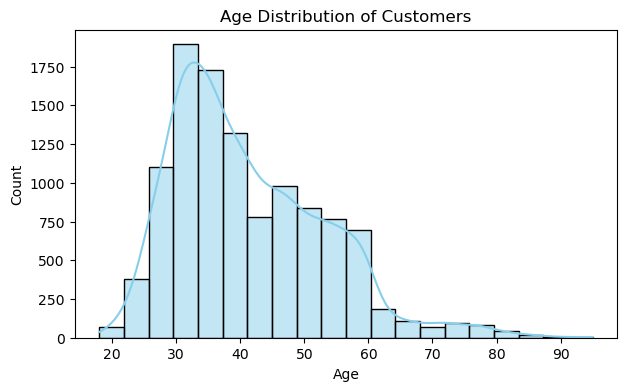

In [4]:
# 1. Distribution of Age
plt.figure(figsize=(7,4))
sns.histplot(df['age'], bins=20, kde=True, color='skyblue')
plt.title("Age Distribution of Customers")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

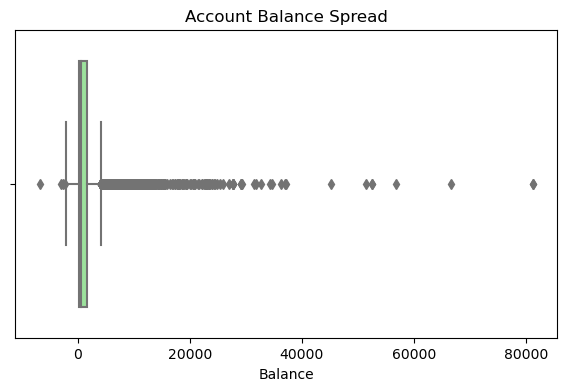

In [5]:
# 2. Distribution of Balance
plt.figure(figsize=(7,4))
sns.boxplot(x=df['balance'], color='lightgreen')
plt.title("Account Balance Spread")
plt.xlabel("Balance")
plt.show()


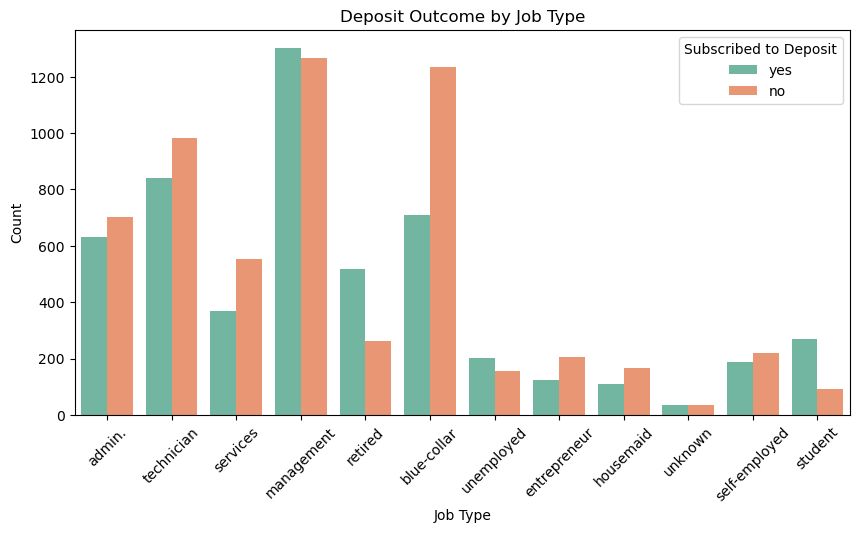

In [6]:
# 3. Job Type vs Deposit Outcome
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='job', hue='deposit', palette='Set2')
plt.title("Deposit Outcome by Job Type")
plt.xticks(rotation=45)
plt.xlabel("Job Type")
plt.ylabel("Count")
plt.legend(title="Subscribed to Deposit")
plt.show()

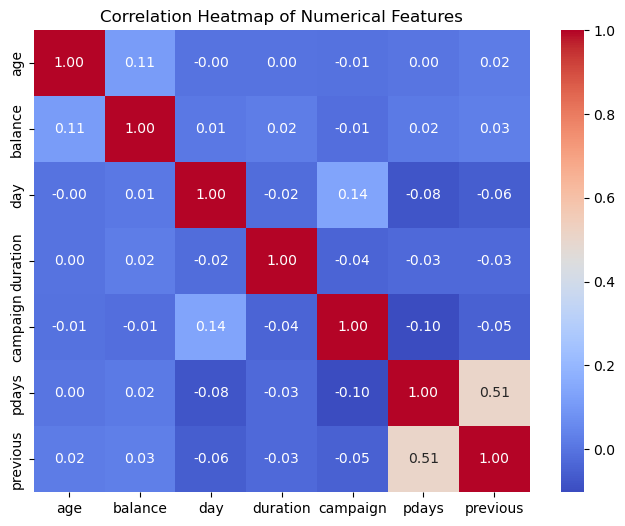

In [7]:
# 4. Correlation Heatmap (numeric features)

numeric_cols = df.select_dtypes(include=['int64', 'float64'])
corr = numeric_cols.corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

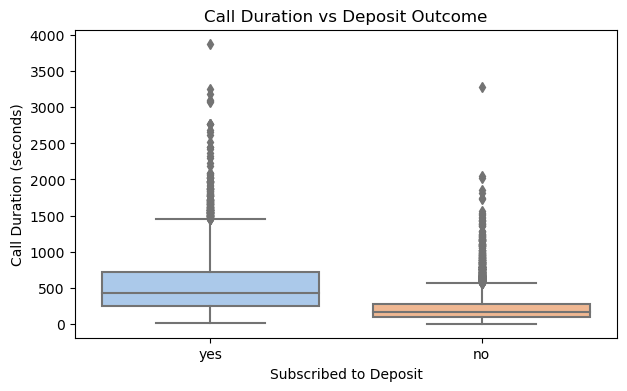

In [8]:
# 5. Duration vs Deposit Outcome
plt.figure(figsize=(7,4))
sns.boxplot(data=df, x='deposit', y='duration', palette='pastel')
plt.title("Call Duration vs Deposit Outcome")
plt.xlabel("Subscribed to Deposit")
plt.ylabel("Call Duration (seconds)")
plt.show()

### Pre-processing the data

In [9]:
# Handle "unknown" values
for col in ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'poutcome']:
    df[col] = df[col].replace('unknown', df[col].mode()[0])

# Encode categorical variables
le = LabelEncoder()
cat_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'poutcome', 'deposit']

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

# Select relevant features
features = ['age', 'job', 'marital', 'education', 'balance', 'housing', 'loan', 'duration']
X = df[features]

# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame for readability
X_scaled_df = pd.DataFrame(X_scaled, columns=features)

print("Preprocessing Complete ")
print("\nSample of Scaled Data:")
print(X_scaled_df.head())

Preprocessing Complete 

Sample of Scaled Data:
        age       job   marital  education   balance   housing      loan  \
0  1.491505 -1.395985 -0.318672  -0.300320  0.252525  1.055280 -0.387923   
1  1.239676 -1.395985 -0.318672  -0.300320 -0.459974 -0.947616 -0.387923   
2 -0.019470  1.431163 -0.318672  -0.300320 -0.080160  1.055280 -0.387923   
3  1.155733  0.802908 -0.318672  -0.300320  0.293762  1.055280 -0.387923   
4  1.071790 -1.395985 -0.318672   1.231052 -0.416876 -0.947616 -0.387923   

   duration  
0  1.930226  
1  3.154612  
2  2.929901  
3  0.596366  
4  0.867171  


### Modeling (Clustering)

C:\Users\rvada\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\rvada\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\rvada\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\rvada\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of

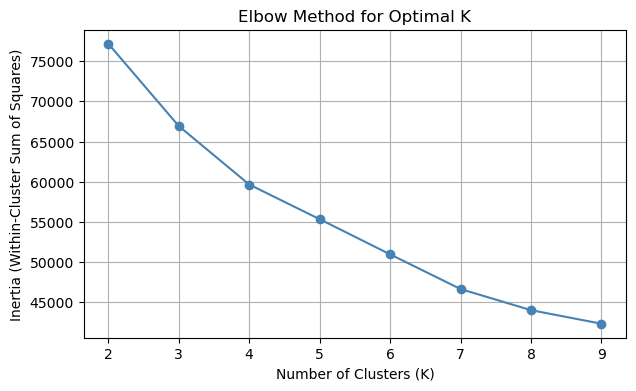

In [30]:
X = X_scaled_df.copy()

# 1. Elbow Method for Optimal K
inertia = []
K_range = range(2, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(7,4))
plt.plot(K_range, inertia, 'o-', color='steelblue')
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia (Within-Cluster Sum of Squares)")
plt.grid(True)
plt.show()

C:\Users\rvada\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


Silhouette Score for K-Means: 0.174


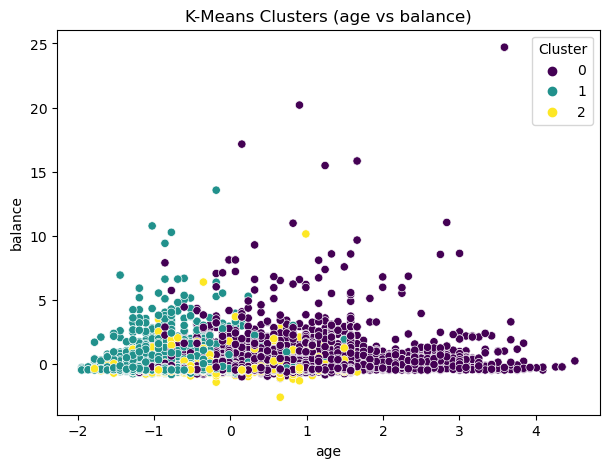

In [31]:
# 2. K-Means Clustering (using K=3 or 4 based on elbow result)
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(X)

X['Cluster'] = kmeans_labels

# Evaluate model using Silhouette Score
silhouette_avg = silhouette_score(X_scaled_df, kmeans_labels)
print(f"Silhouette Score for K-Means: {silhouette_avg:.3f}")

# Visualize clusters using first two features
plt.figure(figsize=(7,5))
sns.scatterplot(data=X, x='age', y='balance', hue='Cluster', palette='viridis')
plt.title("K-Means Clusters (age vs balance)")
plt.show()

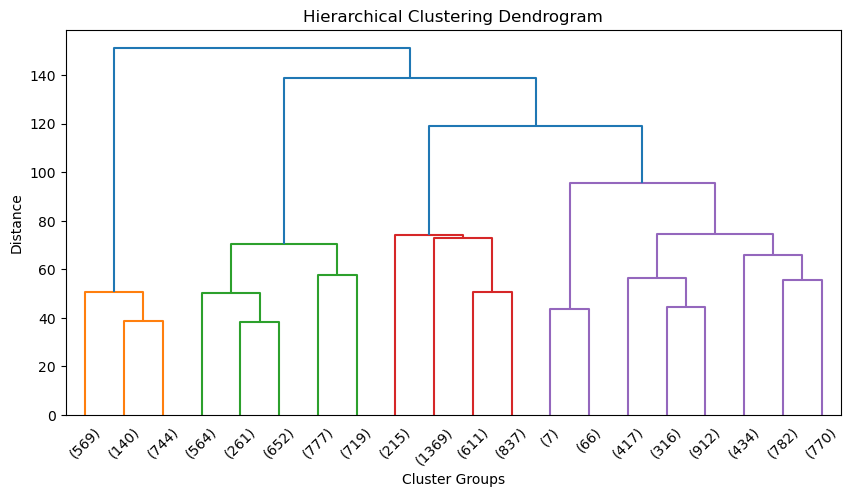

C:\Users\rvada\anaconda3\Lib\site-packages\sklearn\cluster\_agglomerative.py:1005: FutureWarning: Attribute `affinity` was deprecated in version 1.2 and will be removed in 1.4. Use `metric` instead
  warnings.warn(


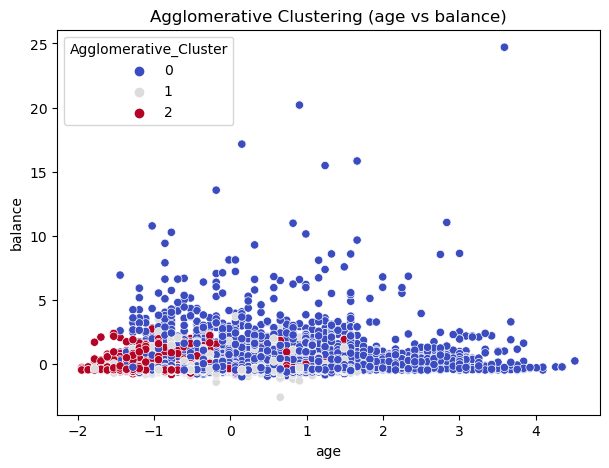

In [32]:
# 3. Hierarchical (Agglomerative) Clustering

# Create linkage matrix for dendrogram
linked = linkage(X_scaled_df, method='ward')

plt.figure(figsize=(10, 5))
dendrogram(linked, truncate_mode='lastp', p=20, leaf_rotation=45., leaf_font_size=10.)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Cluster Groups")
plt.ylabel("Distance")
plt.show()

# Fit Agglomerative Clustering with the same K as K-Means
agg = AgglomerativeClustering(n_clusters=3, affinity='euclidean', linkage='ward')
agg_labels = agg.fit_predict(X_scaled_df)

X['Agglomerative_Cluster'] = agg_labels

# Visualize Agglomerative Clusters
plt.figure(figsize=(7,5))
sns.scatterplot(data=X, x='age', y='balance', hue='Agglomerative_Cluster', palette='coolwarm')
plt.title("Agglomerative Clustering (age vs balance)")
plt.show()